In [ ]:
example = {
        "pipe_inner_radius": 0.11,
        "annular_radius": 0.13,
        "rock_radius": 0.14,
        "base_depth": 3600,
        "top_depth": 3200,
        "pipe_wt": 0.02,
        "fluid_wt": 0.01,
        "rock_wt": 14.87
    }

print(type(example))

<class 'dict'>


In [31]:
layers_depths = [3300, 3400, 3500]

data = {
    "ROCK": {"inner_radius": example["rock_radius"],
                "top_depth": example["top_depth"],
                "base_depth": example["base_depth"],
                "thickness": example["rock_wt"],
                "layer_depths": layers_depths
                },

    "FLUID": {"inner_radius": example["annular_radius"],
                "top_depth": example["top_depth"],
                "base_depth": example["base_depth"],
                "thickness": example["fluid_wt"],
                "layer_depths": layers_depths
                },
    "PIPE": {"inner_radius": example["pipe_inner_radius"],
                "top_depth": example["top_depth"],
                "base_depth": example["base_depth"],
                "thickness": example["pipe_wt"],
                "layer_depths": layers_depths
                },
}

print(type(layers_depths))
print(type(data))
print(data.get('ROCK').get('top_depth'))

<class 'list'>
<class 'dict'>
3200


In [21]:
import numpy as np 

a = np.array([[1, 1, 1],[1,2,3],[1,4,2]])
b = np.array([[1,2,3]])

c = np.dot(b,a)

d = np.transpose(c)

print(a)
print(np.shape(a))
print(b)
print(np.shape(b))
print(c)
print(np.shape(c))

print(d)
print(np.shape(d))

[[1 1 1]
 [1 2 3]
 [1 4 2]]
(3, 3)
[[1 2 3]]
(1, 3)
[[ 6 17 13]]
(1, 3)
[[ 6]
 [17]
 [13]]
(3, 1)


In [4]:
import json 
# import os

# Defining the file paths

json_file_path = r'C:\Users\hidalgo\Documents\GitHub\Abaqus_WELL_\wellClosure_axi.json'
target_script_path = r'C:\Users\hidalgo\Documents\GitHub\Abaqus_WELL_\TestMain.py'

# Reading the paramater from the JSON file

try:
    with open(json_file_path, 'r') as f:
        config_data = json.load(f)


    # --- Navigate through the nested structure to get the value ---
    seawater_depth_json = config_data['ThermalGradient']['seawater'][0]['Depth']

    # Print the result
    print(f"The temperature is: {seawater_depth_json}")
    print(config_data.keys())
    print(config_data['Tubulars']['VAM_13_375_#72_P110'].keys())

    tubular_keys = list(config_data['Tubulars'].keys())  # to refer the keys as numbers
    print(tubular_keys[0])

    selected_tubular_key = tubular_keys[0]
    print(f"Selected tubular: {selected_tubular_key}")
    tubular_data = config_data['Tubulars'][selected_tubular_key]
    print(f"Data: {tubular_data}")

except FileNotFoundError:
    print(f"Error: The file {json_file_path} was not found.")
    exit()  
except json.JSONDecodeError:
    print(f"Error: The file {json_file_path} is not a valid JSON file.")
    exit()

The temperature is: 2000.0
dict_keys(['AnalysisData', 'ThermalGradient', 'Tubulars', 'Lithology', 'InSituStresses', 'Rocks', 'Cements', 'SteelGrades', 'Phases', 'Events', 'Fluids'])
dict_keys(['OD', 'Thickness', 'MinThickness', 'Ovality', 'Material'])
VAM_16in_#97_P110
Selected tubular: VAM_16in_#97_P110
Data: {'OD': 16.0, 'Thickness': 0.575, 'MinThickness': 87.5, 'Ovality': 0.6, 'Material': 'P110'}


In [106]:
import json 
# import os
import numpy as np

# Defining the file paths

json_file_path = r'C:\Users\hidalgo\Documents\GitHub\Abaqus_WELL_\wellClosure_axi.json'
target_script_path = r'C:\Users\hidalgo\Documents\GitHub\Abaqus_WELL_\TestMain.py'

# Reading the paramater from the JSON file

try:
    with open(json_file_path, 'r') as f:
        config_data = json.load(f)

    Config_data_keys = list(config_data.keys())  # to refer the keys as numbers

    # for i in range(len(Config_data_keys)):
    #     print(f"{i+1}: {Config_data_keys[i]}")
    
    AnalysisData_keys = list(config_data[Config_data_keys[0]].keys())  # to refer the keys as numbers

    # for i in range(len(AnalysisData_keys)):
    #     print(f"{i+1}: {AnalysisData_keys[i]}")

    well_top = config_data[Config_data_keys[0]][AnalysisData_keys[2]]
    well_bottom = config_data[Config_data_keys[0]][AnalysisData_keys[3]]

    # print(f"Well Top: {well_top}")
    # print(f"Well Bottom: {well_bottom}")

    # Getting Thermal Gradient Data #######################################################################################

    ThermalGradient_keys = list(config_data[Config_data_keys[1]].keys())  # to refer the keys as numbers

    # for i in range(len(ThermalGradient_keys)):
    #     print(f"{i+1}: {ThermalGradient_keys[i]}")

    Geothermal_cold_keys = list(config_data[Config_data_keys[1]][ThermalGradient_keys[0]])  # to refer the keys as numbers

    geothermal_cold_depths = []
    geothermal_cold_temps = []
    
    for i in range(len(Geothermal_cold_keys)):

        geothermal_cold_depths.append(config_data[Config_data_keys[1]][ThermalGradient_keys[0]][i]['Depth'])
        geothermal_cold_temps.append(config_data[Config_data_keys[1]][ThermalGradient_keys[0]][i]['Temperature'])
        # print(f"{i+1}: {Geothermal_cold_keys[i]}")

    geothermal_cold_depths = np.array(geothermal_cold_depths)
    geothermal_cold_temps = np.array(geothermal_cold_temps)
    
    # print(f"Geothermal Cold Depths: {geothermal_cold_depths}")
    # print(f"Geothermal Cold Temps: {geothermal_cold_temps}")

    # print(type(geothermal_cold_depths))
    # print(type(geothermal_cold_temps))

    Seawater_keys = list(config_data[Config_data_keys[1]][ThermalGradient_keys[1]])  # to refer the keys as numbers

    seawater_depths = []
    seawater_temps = []

    for i in range(len(Seawater_keys)):
        seawater_depths.append(config_data[Config_data_keys[1]][ThermalGradient_keys[1]][i]['Depth'])
        seawater_temps.append(config_data[Config_data_keys[1]][ThermalGradient_keys[1]][i]['Temperature'])
        # print(f"{i+1}: {Seawater_keys[i]}")

    seawater_depths = np.array(seawater_depths)
    seawater_temps = np.array(seawater_temps)

    # print(f"Seawater Depths: {seawater_depths}")
    # print(f"Seawater Temps: {seawater_temps}")

    temp_drilling_phase_1_keys = list(config_data[Config_data_keys[1]][ThermalGradient_keys[2]])  # to refer the keys as numbers
    temp_drilling_phase_1_depths = []
    temp_drilling_phase_1_temps = []

    for i in range(len(temp_drilling_phase_1_keys)):
        temp_drilling_phase_1_depths.append(config_data[Config_data_keys[1]][ThermalGradient_keys[2]][i]['Depth'])
        temp_drilling_phase_1_temps.append(config_data[Config_data_keys[1]][ThermalGradient_keys[2]][i]['Temperature'])
        # print(f"{i+1}: {temp_drilling_phase_1_keys[i]}")

    temp_drilling_phase_1_depths = np.array(temp_drilling_phase_1_depths)
    temp_drilling_phase_1_temps = np.array(temp_drilling_phase_1_temps)

    # print(f"Temp Drilling Phase 1 Depths: {temp_drilling_phase_1_depths}")
    # print(f"Temp Drilling Phase 1 Temps: {temp_drilling_phase_1_temps}")

    temp_drilling_phase_2_keys = list(config_data[Config_data_keys[1]][ThermalGradient_keys[3]])  # to refer the keys as numbers    
    temp_drilling_phase_2_depths = []
    temp_drilling_phase_2_temps = []

    for i in range(len(temp_drilling_phase_2_keys)):
        temp_drilling_phase_2_depths.append(config_data[Config_data_keys[1]][ThermalGradient_keys[3]][i]['Depth'])
        temp_drilling_phase_2_temps.append(config_data[Config_data_keys[1]][ThermalGradient_keys[3]][i]['Temperature'])
        # print(f"{i+1}: {temp_drilling_phase_2_keys[i]}")

    temp_drilling_phase_2_depths = np.array(temp_drilling_phase_2_depths)
    temp_drilling_phase_2_temps = np.array(temp_drilling_phase_2_temps)

    # print(f"Temp Drilling Phase 2 Depths: {temp_drilling_phase_2_depths}")
    # print(f"Temp Drilling Phase 2 Temps: {temp_drilling_phase_2_temps}")

    temp_drilling_d1_keys = list(config_data[Config_data_keys[1]][ThermalGradient_keys[4]])  # to refer the keys as numbers
    temp_drilling_d1_depths = []
    temp_drilling_d1_temps = []

    for i in range(len(temp_drilling_d1_keys)):
        temp_drilling_d1_depths.append(config_data[Config_data_keys[1]][ThermalGradient_keys[4]][i]['Depth'])
        temp_drilling_d1_temps.append(config_data[Config_data_keys[1]][ThermalGradient_keys[4]][i]['Temperature'])
        # print(f"{i+1}: {temp_drilling_d1_keys[i]}")

    temp_drilling_d1_depths = np.array(temp_drilling_d1_depths)
    temp_drilling_d1_temps = np.array(temp_drilling_d1_temps)

    # print(f"Temp Drilling D1 Depths: {temp_drilling_d1_depths}")
    # print(f"Temp Drilling D1 Temps: {temp_drilling_d1_temps}")

    temp_drilling_d2_keys = list(config_data[Config_data_keys[1]][ThermalGradient_keys[5]])  # to refer the keys as numbers
    temp_drilling_d2_depths = []
    temp_drilling_d2_temps = []
    
    for i in range(len(temp_drilling_d2_keys)):
        temp_drilling_d2_depths.append(config_data[Config_data_keys[1]][ThermalGradient_keys[5]][i]['Depth'])
        temp_drilling_d2_temps.append(config_data[Config_data_keys[1]][ThermalGradient_keys[5]][i]['Temperature'])
        # print(f"{i+1}: {temp_drilling_d2_keys[i]}")

    temp_drilling_d2_depths = np.array(temp_drilling_d2_depths)
    temp_drilling_d2_temps = np.array(temp_drilling_d2_temps)

    # print(f"Temp Drilling D2 Depths: {temp_drilling_d2_depths}")
    # print(f"Temp Drilling D2 Temps: {temp_drilling_d2_temps}")

    geothermal_warm_keys = list(config_data[Config_data_keys[1]][ThermalGradient_keys[6]])  # to refer the keys as numbers
    # print(geothermal_warm_keys)
    
    geothermal_warm_depths = []
    geothermal_warm_temps = []

    for i in range(len(geothermal_warm_keys)):
        geothermal_warm_depths.append(config_data[Config_data_keys[1]][ThermalGradient_keys[6]][i]['Depth'])
        geothermal_warm_temps.append(config_data[Config_data_keys[1]][ThermalGradient_keys[6]][i]['Temperature'])
        # print(f"{i+1}: {geothermal_warm_keys[i]}")

    geothermal_warm_depths = np.array(geothermal_warm_depths)
    geothermal_warm_temps = np.array(geothermal_warm_temps)

    # print(f"Geothermal Warm Depths: {geothermal_warm_depths}")
    # print(f"Geothermal Warm Temps: {geothermal_warm_temps}")

    production_annulus_keys = list(config_data[Config_data_keys[1]][ThermalGradient_keys[7]])  # to refer the keys as numbers
    production_annulus_depths = []
    production_annulus_temps = []

    for i in range(len(production_annulus_keys)):
        production_annulus_depths.append(config_data[Config_data_keys[1]][ThermalGradient_keys[7]][i]['Depth'])
        production_annulus_temps.append(config_data[Config_data_keys[1]][ThermalGradient_keys[7]][i]['Temperature'])
        # print(f"{i+1}: {production_annulus_keys[i]}")

    production_annulus_depths = np.array(production_annulus_depths)
    production_annulus_temps = np.array(production_annulus_temps)

    # print(f"Production Annulus Depths: {production_annulus_depths}")
    # print(f"Production Annulus Temps: {production_annulus_temps}")

    # Getting Tubulars Geometric Data #######################################################################################

    tubular_keys = list(config_data[Config_data_keys[2]].keys())  # to refer the keys as numbers
    
    # name_tubular = 'VAM_16in_#97_P110'
    # name_tubular = '22_0IN_251_0NW_X70'
    name_tubular = 'TEN_30_#161.33_X56'

    # for i in range(len(tubular_keys)):
    #     print(f"{i+1}: {tubular_keys[i]}")
 
    if name_tubular in tubular_keys:
        od_pipe1 = config_data[Config_data_keys[2]][name_tubular]['OD']
        thickness_pipe1 = config_data[Config_data_keys[2]][name_tubular]['Thickness']
        material_pipe1 = config_data[Config_data_keys[2]][name_tubular]['Material']
        inner_radius_pipe_json = od_pipe1 / 2 - thickness_pipe1 # inner radius of the pipe in inches
    else:
        od_pipe1 = None
        thickness_pipe1 = None
        material_pipe1 = None
        inner_radius_pipe_json = None
        print("Tubular not found.")

    # print(f"OD of the pipe {name_tubular} is: {od_pipe1}") 
    # print(f"Thickness of the pipe {name_tubular} is: {thickness_pipe1}") 
    # print(f"Material of the pipe {name_tubular} is: {material_pipe1}")   

    # Getting Lithology Data #######################################################################################
    # 
    
    lithology_keys = list(config_data[Config_data_keys[3]])  # to refer the keys as numbers

    # for i in range(len(lithology_keys)):
    #     print(f"{i+1}: {lithology_keys[i]}")

    rocks_list = [rock['Rock'] for rock in lithology_keys]

    # collecting all 'Top' depths and the last 'Bottom' depth
    depths = [rock['Top'] for rock in lithology_keys] + [lithology_keys[-1]['Bottom']]

    # Getting the unique depths, sort them, and converting to a numpy array
    depths_array = np.array(sorted(set(depths)))

    # print(f"Depths Array: {depths_array}")

    # Getting InSituStresses Data #######################################################################################

    insitu_keys = list(config_data[Config_data_keys[4]])  # to refer the keys as numbers
    # tubular1_keys = list(config_data[Config_data_keys[2]][tubular_keys[0]].keys())  # to refer the keys as numbers
    
    depths_insitu = [stress['Depth'] for stress in insitu_keys]
    # print(depths_insitu)

    depth_analysis = 4150.0

    # for i in range(len(tubular_keys)):
    #     print(f"{i+1}: {tubular_keys[i]}")
 
    if depth_analysis in depths_insitu:
        index = depths_insitu.index(depth_analysis)
        overburden_insitu = insitu_keys[index]['Overburden']
        sh_max_insitu = insitu_keys[index]['ShMax']
        sh_min_insitu = insitu_keys[index]['ShMin']
        pore_pressure_insitu = insitu_keys[index]['PorePressure']
    else:
        overburden_insitu = None
        sh_max_insitu = None
        sh_min_insitu = None
        pore_pressure_insitu = None
        print("Depth not found in InSituStresses.")

    # print(f"Overburden at depth {depth_analysis} m is: {overburden_insitu} MPa")
    # print(f"ShMax at depth {depth_analysis} m is: {sh_max_insitu} MPa")
    # print(f"ShMin at depth {depth_analysis} m is: {sh_min_insitu} MPa")
    # print(f"Pore Pressure at depth {depth_analysis} m is: {pore_pressure_insitu} MPa")

    # Getting Rocks Material properties Data #######################################################################################

    # This is similar to tubular data in which we have a list of different tubulars 
    rocks_properties_keys = list(config_data[Config_data_keys[5]])  # to refer the keys as numbers

    # for i in range(len(rocks_properties_keys)):
    #     print(f"{i+1}: {rocks_properties_keys[i]}")

    # name_rock = 'SHALE'
    name_rock = 'HALITE'
    # name_rock = 'TACHYHYDRITE'

    halite_properties_keys = list(config_data[Config_data_keys[5]]['HALITE'].keys())  # to refer the keys as numbers


 
    if name_rock in rocks_properties_keys:
        DPL_s0 = config_data[Config_data_keys[5]][name_rock][halite_properties_keys[0]]['s0']
        DPL_a1 = config_data[Config_data_keys[5]][name_rock][halite_properties_keys[0]]['a1']
        DPL_a2 = config_data[Config_data_keys[5]][name_rock][halite_properties_keys[0]]['a2']
        DPL_b1 = config_data[Config_data_keys[5]][name_rock][halite_properties_keys[0]]['b1']
        DPL_b2 = config_data[Config_data_keys[5]][name_rock][halite_properties_keys[0]]['b2']
        DPL_c1 = config_data[Config_data_keys[5]][name_rock][halite_properties_keys[0]]['c1']
        DPL_c2 = config_data[Config_data_keys[5]][name_rock][halite_properties_keys[0]]['c2']
    else:
        DPL_s0 = None
        DPL_a1 = None
        DPL_a2 = None
        DPL_b1 = None
        DPL_b2 = None
        DPL_c1 = None
        DPL_c2 = None
        print("Rock not found.")

    # print(f"DPL s0 of the rock {name_rock} is: {DPL_s0}")
    # print(f"DPL a1 of the rock {name_rock} is: {DPL_a1}")
    # print(f"DPL a2 of the rock {name_rock} is: {DPL_a2}")
    # print(f"DPL b1 of the rock {name_rock} is: {DPL_b1}")
    # print(f"DPL b2 of the rock {name_rock} is: {DPL_b2}")
    # print(f"DPL c1 of the rock {name_rock} is: {DPL_c1}")
    # print(f"DPL c2 of the rock {name_rock} is: {DPL_c2}")

    # Getting SteelGrades Material properties Data #######################################################################################
 
    steelgrades_keys = list(config_data[Config_data_keys[7]])  # to refer the keys as numbers

    # for i in range(len(steelgrades_keys)):
    #     print(f"{i+1}: {steelgrades_keys[i]}")

    name_steelgrade = 'P110'

    steelgrades_properties_keys = list(config_data[Config_data_keys[7]][name_steelgrade].keys())  # to refer the keys as numbers
    
    metal_sy = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[0]]['sy']
    metal_sUlt = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[0]]['sUlt']
    metal_epUlt = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[0]]['epUlt']
    metal_density = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[3]]['Density']
    metal_young_modulus = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[3]]['Young']
    metal_poisson = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[3]]['Poisson']
    metal_conductivity = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[4]]['Conductivity']
    metal_specific_heat = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[4]]['SpecificHeat']
    metal_thermal_expansion = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[4]]['ThermalExpansion']

    # print(f"The sy of the metal is {metal_sy}.")
    # print(f"The Ultimate Strength of the metal is {metal_sUlt}.")
    # print(f"The Ultimate Strain of the metal is {metal_epUlt}.")
    # print(f"The Young's Modulus of the metal is {metal_young_modulus}.")
    # print(f"The Poisson's Ratio of the metal is {metal_poisson}.")
    # print(f"The Density of the metal is {metal_density}.")
    # print(f"The Conductivity of the metal is {metal_conductivity}.")
    # print(f"The Specific Heat of the metal is {metal_specific_heat}.")
    # print(f"The Thermal Expansion of the metal is {metal_thermal_expansion}.")

    # Getting Phases Data #######################################################################################

    phases_keys = list(config_data[Config_data_keys[8]])  # to refer the keys as numbers

    # for i in range(len(phases_keys)):
    #     print(f"{i+1}: {phases_keys[i]}")

    phase1_hole_diameter = config_data[Config_data_keys[8]][phases_keys[0]]['HoleDiameter']
    phase1_hole_radius = phase1_hole_diameter / 2

    # print(phase1_hole_diameter)




    # Getting Fluids Data #######################################################################################

    fluids_keys = list(config_data[Config_data_keys[10]])  # to refer the keys as numbers

    # for i in range(len(fluids_keys)):
    #     print(f"{i+1}: {fluids_keys[i]}")

    sea_water_density = config_data[Config_data_keys[10]][fluids_keys[0]]['Density']
    drilling_phase_1_density = config_data[Config_data_keys[10]][fluids_keys[1]]['Density']
    drilling_d1_density = config_data[Config_data_keys[10]][fluids_keys[2]]['Density']
    drilling_d2_density = config_data[Config_data_keys[10]][fluids_keys[3]]['Density']
    drilling_d3_density = config_data[Config_data_keys[10]][fluids_keys[4]]['Density']
    drilling_d4_density = config_data[Config_data_keys[10]][fluids_keys[5]]['Density']
    drilling_d5_density = config_data[Config_data_keys[10]][fluids_keys[6]]['Density']
    mud_weight_density = config_data[Config_data_keys[10]][fluids_keys[7]]['Density']
    production_annulusA_density = config_data[Config_data_keys[10]][fluids_keys[8]]['Density']
    
    # print(f"The density of sea water is {sea_water_density} ppg.")
    # print(f"The density of drilling phase 1 is {drilling_phase_1_density} ppg.")
    # print(f"The density of drilling d1 is {drilling_d1_density} ppg.")
    # print(f"The density of drilling d2 is {drilling_d2_density} ppg.")
    # print(f"The density of drilling d3 is {drilling_d3_density} ppg.")
    # print(f"The density of drilling d4 is {drilling_d4_density} ppg.")
    # print(f"The density of drilling d5 is {drilling_d5_density} ppg.")
    # print(f"The density of mud weight is {mud_weight_density} ppg.")
    # print(f"The density of production annulus A is {production_annulusA_density} ppg.")

except FileNotFoundError:
    print(f"Error: The file {json_file_path} was not found.")
    exit()  
except json.JSONDecodeError:
    print(f"Error: The file {json_file_path} is not a valid JSON file.")
    exit()

In [110]:
# Converting the inner radius of the pipe to meters in the target script

inner_radius_pipe_json = inner_radius_pipe_json * 0.0254  # converting inches to meters
thickness_pipe1 = thickness_pipe1 * 0.0254  # converting inches to meters

phase1_hole_radius = phase1_hole_radius * 0.0254  # converting inches to meters

In [111]:
# Reading the content of the target Python script

try:
    with open(target_script_path, 'r') as f:
        # Reading all the lines of the file into a list
        script_lines = f.readlines()
    
except FileNotFoundError:
    print(f"Error: The file {target_script_path} was not found.")
    exit()

In [112]:
# Finding the line to modify and change the parameter value
new_script_lines = []
modified = False
# The string we are looking for to identify the line
# target_line_start = "inner_radius_pipe ="
target_line_start = "thickness_pipe ="
# target_line_start = "inner_radius_wellbore ="
# target_line_start = "base_depth ="
# target_line_start = "top_depth ="

for line in script_lines:
    if line.strip().startswith(target_line_start):
        # Constructing the new line with the updated parameter value
        # new_line = f"{target_line_start} {inner_radius_pipe_json}  # Updated by script\n"
        new_line = f"{target_line_start} {thickness_pipe1}  # Updated by script\n"
        # new_line = f"{target_line_start} {phase1_hole_radius}  # Updated by script\n"
        # new_line = f"{target_line_start} {well_bottom}  # Updated by script\n"
        # new_line = f"{target_line_start} {well_top}  # Updated by script\n"
        new_script_lines.append(new_line)
        modified = True
        print(f"Found and replaced line: {new_line.strip()}")
        print(f"New line: '{new_line.strip()}'")
    else:
        # If it's not the target line, keep it unchanged
        new_script_lines.append(line)

# Write the modified content back to the target script if modified
if modified:
    with open(target_script_path, 'w') as f:
        f.writelines(new_script_lines)
    print(f"\nSuccessfully updated the '{target_line_start}' variable in {target_script_path}.")
else:
    print(f"\nWarning: Could not find a line starting with '{target_line_start}' in {target_script_path}. No changes were made.")

Found and replaced line: thickness_pipe = 0.0127  # Updated by script
New line: 'thickness_pipe = 0.0127  # Updated by script'

Successfully updated the 'thickness_pipe =' variable in C:\Users\hidalgo\Documents\GitHub\Abaqus_WELL_\TestMain.py.


In [11]:
examples = {
        "STEEL": {
            "behavior": "Elastic",
            'density': 7950,
            'elastic': (206842800000, 0.3),
            'conductivity': 45.3452,
            'specific_heat': 342.2186813
        }, 
        "FLUID": {
            "behavior": "Elastic",
            'density': 1.0,
            'elastic': (10000, 0),
            'conductivity': 0.702
        }, 
        "SHALE": {
            "behavior": "Elastic",
            'density': 2332.73533930301,
            'elastic': (20001698760, 0.29),
            'conductivity': 1.592,
            'specific_heat': 0.209946,
            'expansion': 1.2e-5
        }
    }
 

In [3]:
lythology_examples = [
        {
            "set_name": 'SHALE',
            "top_depth": 3200.0,
            "base_depth": 3550.0,
            "partName": 'ROCK',
            "sectionName": 'SHALE_Section',
        },
        {
            "set_name": 'SANDSTONE',
            "top_depth": 3550.0,
            "base_depth": 3900.0,
            "partName": 'ROCK',
            "sectionName": 'SANDSTONE_Section',
        },
        {
            "set_name": 'HALITE',
            "top_depth": 3900.0,
            "base_depth": 4250.0,
            "partName": 'ROCK',
            "sectionName": 'HALITE_Section',
        }
    ]

print(lythology_examples[1])

{'set_name': 'SANDSTONE', 'top_depth': 3550.0, 'base_depth': 3900.0, 'partName': 'ROCK', 'sectionName': 'SANDSTONE_Section'}


In [3]:
# from abaqus import *
# from abaqusConstants import *

# import os
import sys 

# path_project = r'C:\Users\juani\Documents\Github\Abaqus_WELL_' 
path_project = r'C:\Users\hidalgo\Documents\GitHub\Abaqus_WELL_'

if path_project not in sys.path:
    sys.path.append(path_project)

# from GEOMETRY.geometries import * 
# from GEOMETRY.assembly import *
# from MATERIALS.materials import *             
# from materials_novo import ElasticMaterial
# from ASSEMBLY.assembly import *

# mdb.models.changeKey(fromName='Model-1', toName='MyFirstModel')

# if 'MyFirstModel' not in mdb.models:
#     mdb.Model(name='MyFirstModel')

# variables that have to be changed ####################################################

inner_radius_pipe = 0.36829999999999996  # Updated by script
thickness_pipe = 0.0127  # Updated by script
inner_radius_annular = inner_radius_pipe + thickness_pipe
# thickness_annular = 0.02
# inner_radius_wellbore = inner_radius_annular + thickness_annular
inner_radius_wellbore = 0.4572  # Updated by script
thickness_annular = inner_radius_wellbore - inner_radius_annular
thickness_wellbore = 12.0

base_depth = 4250.0  # Updated by script
base_depth = int(base_depth)
top_depth = 3200.0  # Updated by script
top_depth = int(top_depth)

print(f"inner_radius_pipe = {inner_radius_pipe}")
print(f"thickness_pipe = {thickness_pipe}")
print(f"inner_radius_annular = {inner_radius_annular}")
print(f"thickness_annular = {thickness_annular}")
print(f"inner_radius_wellbore = {inner_radius_wellbore}")
print(f"thickness_wellbore = {thickness_wellbore}")

inner_radius_pipe = 0.36829999999999996
thickness_pipe = 0.0127
inner_radius_annular = 0.38099999999999995
thickness_annular = 0.07620000000000005
inner_radius_wellbore = 0.4572
thickness_wellbore = 12.0


In [1]:
import json 
# import os
import numpy as np

# Defining the file paths

json_file_path = r'C:\Users\hidalgo\Documents\GitHub\Abaqus_WELL_\wellClosure_axi.json'
target_script_path = r'C:\Users\hidalgo\Documents\GitHub\Abaqus_WELL_\TestMain.py'

# Reading the paramater from the JSON file

try:
    with open(json_file_path, 'r') as f:
        config_data = json.load(f)

    Config_data_keys = list(config_data.keys())  # to refer the keys as numbers
   
    AnalysisData_keys = list(config_data[Config_data_keys[0]].keys())  # to refer the keys as numbers

    well_top = config_data[Config_data_keys[0]][AnalysisData_keys[2]]
    well_bottom = config_data[Config_data_keys[0]][AnalysisData_keys[3]]

    # Getting Thermal Gradient Data #######################################################################################

    ThermalGradient_keys = list(config_data[Config_data_keys[1]].keys())  # to refer the keys as numbers

    Geothermal_cold_keys = list(config_data[Config_data_keys[1]][ThermalGradient_keys[0]])  # to refer the keys as numbers

    geothermal_cold_depths = []
    geothermal_cold_temps = []
    
    for i in range(len(Geothermal_cold_keys)):

        geothermal_cold_depths.append(config_data[Config_data_keys[1]][ThermalGradient_keys[0]][i]['Depth'])
        geothermal_cold_temps.append(config_data[Config_data_keys[1]][ThermalGradient_keys[0]][i]['Temperature'])

    geothermal_cold_depths = np.array(geothermal_cold_depths)
    geothermal_cold_temps = np.array(geothermal_cold_temps)
    
    Seawater_keys = list(config_data[Config_data_keys[1]][ThermalGradient_keys[1]])  # to refer the keys as numbers

    seawater_depths = []
    seawater_temps = []

    for i in range(len(Seawater_keys)):
        seawater_depths.append(config_data[Config_data_keys[1]][ThermalGradient_keys[1]][i]['Depth'])
        seawater_temps.append(config_data[Config_data_keys[1]][ThermalGradient_keys[1]][i]['Temperature'])

    seawater_depths = np.array(seawater_depths)
    seawater_temps = np.array(seawater_temps)

    temp_drilling_phase_1_keys = list(config_data[Config_data_keys[1]][ThermalGradient_keys[2]])  # to refer the keys as numbers
    temp_drilling_phase_1_depths = []
    temp_drilling_phase_1_temps = []

    for i in range(len(temp_drilling_phase_1_keys)):
        temp_drilling_phase_1_depths.append(config_data[Config_data_keys[1]][ThermalGradient_keys[2]][i]['Depth'])
        temp_drilling_phase_1_temps.append(config_data[Config_data_keys[1]][ThermalGradient_keys[2]][i]['Temperature'])

    temp_drilling_phase_1_depths = np.array(temp_drilling_phase_1_depths)
    temp_drilling_phase_1_temps = np.array(temp_drilling_phase_1_temps)

    temp_drilling_phase_2_keys = list(config_data[Config_data_keys[1]][ThermalGradient_keys[3]])  # to refer the keys as numbers    
    temp_drilling_phase_2_depths = []
    temp_drilling_phase_2_temps = []

    for i in range(len(temp_drilling_phase_2_keys)):
        temp_drilling_phase_2_depths.append(config_data[Config_data_keys[1]][ThermalGradient_keys[3]][i]['Depth'])
        temp_drilling_phase_2_temps.append(config_data[Config_data_keys[1]][ThermalGradient_keys[3]][i]['Temperature'])

    temp_drilling_phase_2_depths = np.array(temp_drilling_phase_2_depths)
    temp_drilling_phase_2_temps = np.array(temp_drilling_phase_2_temps)


    temp_drilling_d1_keys = list(config_data[Config_data_keys[1]][ThermalGradient_keys[4]])  # to refer the keys as numbers
    temp_drilling_d1_depths = []
    temp_drilling_d1_temps = []

    for i in range(len(temp_drilling_d1_keys)):
        temp_drilling_d1_depths.append(config_data[Config_data_keys[1]][ThermalGradient_keys[4]][i]['Depth'])
        temp_drilling_d1_temps.append(config_data[Config_data_keys[1]][ThermalGradient_keys[4]][i]['Temperature'])

    temp_drilling_d1_depths = np.array(temp_drilling_d1_depths)
    temp_drilling_d1_temps = np.array(temp_drilling_d1_temps)

    temp_drilling_d2_keys = list(config_data[Config_data_keys[1]][ThermalGradient_keys[5]])  # to refer the keys as numbers
    temp_drilling_d2_depths = []
    temp_drilling_d2_temps = []
    
    for i in range(len(temp_drilling_d2_keys)):
        temp_drilling_d2_depths.append(config_data[Config_data_keys[1]][ThermalGradient_keys[5]][i]['Depth'])
        temp_drilling_d2_temps.append(config_data[Config_data_keys[1]][ThermalGradient_keys[5]][i]['Temperature'])

    temp_drilling_d2_depths = np.array(temp_drilling_d2_depths)
    temp_drilling_d2_temps = np.array(temp_drilling_d2_temps)

    geothermal_warm_keys = list(config_data[Config_data_keys[1]][ThermalGradient_keys[6]])  # to refer the keys as numbers
    
    geothermal_warm_depths = []
    geothermal_warm_temps = []

    for i in range(len(geothermal_warm_keys)):
        geothermal_warm_depths.append(config_data[Config_data_keys[1]][ThermalGradient_keys[6]][i]['Depth'])
        geothermal_warm_temps.append(config_data[Config_data_keys[1]][ThermalGradient_keys[6]][i]['Temperature'])

    geothermal_warm_depths = np.array(geothermal_warm_depths)
    geothermal_warm_temps = np.array(geothermal_warm_temps)

    production_annulus_keys = list(config_data[Config_data_keys[1]][ThermalGradient_keys[7]])  # to refer the keys as numbers
    production_annulus_depths = []
    production_annulus_temps = []

    for i in range(len(production_annulus_keys)):
        production_annulus_depths.append(config_data[Config_data_keys[1]][ThermalGradient_keys[7]][i]['Depth'])
        production_annulus_temps.append(config_data[Config_data_keys[1]][ThermalGradient_keys[7]][i]['Temperature'])

    production_annulus_depths = np.array(production_annulus_depths)
    production_annulus_temps = np.array(production_annulus_temps)

    # Getting Tubulars Geometric Data #######################################################################################

    tubular_keys = list(config_data[Config_data_keys[2]].keys())  # to refer the keys as numbers
    
    # name_tubular = 'VAM_16in_#97_P110'
    # name_tubular = '22_0IN_251_0NW_X70'
    name_tubular = 'TEN_30_#161.33_X56'
 
    if name_tubular in tubular_keys:
        od_pipe1 = config_data[Config_data_keys[2]][name_tubular]['OD']
        thickness_pipe1 = config_data[Config_data_keys[2]][name_tubular]['Thickness']
        material_pipe1 = config_data[Config_data_keys[2]][name_tubular]['Material']
        inner_radius_pipe1_json = od_pipe1 / 2 - thickness_pipe1
    else:
        od_pipe1 = None
        thickness_pipe1 = None
        material_pipe1 = None
        inner_radius_pipe1_json = None
        print("Tubular not found.")

    # Getting Lithology Data #######################################################################################
    # 
    
    lithology_keys = list(config_data[Config_data_keys[3]])  # to refer the keys as numbers

    rocks_list = [rock['Rock'] for rock in lithology_keys]

    # collecting all 'Top' depths and the last 'Bottom' depth
    depths = [rock['Top'] for rock in lithology_keys] + [lithology_keys[-1]['Bottom']]

    # Getting the unique depths, sort them, and converting to a numpy array
    depths_array = np.array(sorted(set(depths)))

    # Getting InSituStresses Data #######################################################################################

    insitu_keys = list(config_data[Config_data_keys[4]])  # to refer the keys as numbers
    # tubular1_keys = list(config_data[Config_data_keys[2]][tubular_keys[0]].keys())  # to refer the keys as numbers
    
    depths_insitu = [stress['Depth'] for stress in insitu_keys]

    depth_analysis = 4150.0
 
    if depth_analysis in depths_insitu:
        index = depths_insitu.index(depth_analysis)
        overburden_insitu = insitu_keys[index]['Overburden']
        sh_max_insitu = insitu_keys[index]['ShMax']
        sh_min_insitu = insitu_keys[index]['ShMin']
        pore_pressure_insitu = insitu_keys[index]['PorePressure']
    else:
        overburden_insitu = None
        sh_max_insitu = None
        sh_min_insitu = None
        pore_pressure_insitu = None
        print("Depth not found in InSituStresses.")

    # Getting Rocks Material properties Data #######################################################################################

    # This is similar to tubular data in which we have a list of different tubulars 
    rocks_properties_keys = list(config_data[Config_data_keys[5]])  # to refer the keys as numbers

    # name_rock = 'SHALE'
    name_rock = 'HALITE'
    # name_rock = 'TACHYHYDRITE'

    halite_properties_keys = list(config_data[Config_data_keys[5]]['HALITE'].keys())  # to refer the keys as numbers
 
    if name_rock in rocks_properties_keys:
        DPL_s0 = config_data[Config_data_keys[5]][name_rock][halite_properties_keys[0]]['s0']
        DPL_a1 = config_data[Config_data_keys[5]][name_rock][halite_properties_keys[0]]['a1']
        DPL_a2 = config_data[Config_data_keys[5]][name_rock][halite_properties_keys[0]]['a2']
        DPL_b1 = config_data[Config_data_keys[5]][name_rock][halite_properties_keys[0]]['b1']
        DPL_b2 = config_data[Config_data_keys[5]][name_rock][halite_properties_keys[0]]['b2']
        DPL_c1 = config_data[Config_data_keys[5]][name_rock][halite_properties_keys[0]]['c1']
        DPL_c2 = config_data[Config_data_keys[5]][name_rock][halite_properties_keys[0]]['c2']
    else:
        DPL_s0 = None
        DPL_a1 = None
        DPL_a2 = None
        DPL_b1 = None
        DPL_b2 = None
        DPL_c1 = None
        DPL_c2 = None
        print("Rock not found.")

    # Getting SteelGrades Material properties Data #######################################################################################
 
    steelgrades_keys = list(config_data[Config_data_keys[7]])  # to refer the keys as numbers

    name_steelgrade = 'P110'

    steelgrades_properties_keys = list(config_data[Config_data_keys[7]][name_steelgrade].keys())  # to refer the keys as numbers
    
    metal_sy = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[0]]['sy']
    metal_sUlt = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[0]]['sUlt']
    metal_epUlt = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[0]]['epUlt']
    metal_density = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[3]]['Density']
    metal_young_modulus = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[3]]['Young']
    metal_poisson = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[3]]['Poisson']
    metal_conductivity = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[4]]['Conductivity']
    metal_specific_heat = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[4]]['SpecificHeat']
    metal_thermal_expansion = config_data[Config_data_keys[7]][name_steelgrade][steelgrades_properties_keys[4]]['ThermalExpansion']

    # Getting Phases Data #######################################################################################

    phases_keys = list(config_data[Config_data_keys[8]])  # to refer the keys as numbers


    # Getting Fluids Data #######################################################################################

    fluids_keys = list(config_data[Config_data_keys[10]])  # to refer the keys as numbers

    sea_water_density = config_data[Config_data_keys[10]][fluids_keys[0]]['Density']
    drilling_phase_1_density = config_data[Config_data_keys[10]][fluids_keys[1]]['Density']
    drilling_d1_density = config_data[Config_data_keys[10]][fluids_keys[2]]['Density']
    drilling_d2_density = config_data[Config_data_keys[10]][fluids_keys[3]]['Density']
    drilling_d3_density = config_data[Config_data_keys[10]][fluids_keys[4]]['Density']
    drilling_d4_density = config_data[Config_data_keys[10]][fluids_keys[5]]['Density']
    drilling_d5_density = config_data[Config_data_keys[10]][fluids_keys[6]]['Density']
    mud_weight_density = config_data[Config_data_keys[10]][fluids_keys[7]]['Density']
    production_annulusA_density = config_data[Config_data_keys[10]][fluids_keys[8]]['Density']

except FileNotFoundError:
    print(f"Error: The file {json_file_path} was not found.")
    exit()  
except json.JSONDecodeError:
    print(f"Error: The file {json_file_path} is not a valid JSON file.")
    exit()

In [5]:
import json

with open(r'C:\Users\hidalgo\Documents\GitHub\Abaqus_WELL_\wellClosure_axi.json') as f:
    data = json.load(f)

teste = data["AnalysisData"]["Bottom"]
teste = int(teste)

print(type(teste))

<class 'int'>


In [31]:
import json
from pprint import pprint

with open(r'C:\Users\hidalgo\Documents\GitHub\Abaqus_WELL_\wellClosure_axi.json') as f:
    data = json.load(f)

    rocha = "HALITE"

teste = data["Rocks"][rocha]["DoublePowerParameters"]
# teste = data.get("DoublePowerParameters", {})

pprint(teste)

A2 = data.get("a2")

print(A2)

{'a1': 0.0077864,
 'a2': 0.0076093,
 'b1': 6042.905,
 'b2': 6042.905,
 'c1': 2.94,
 'c2': 8.15,
 's0': 10.300006}
None


In [ ]:
import json
from pprint import pprint
# with open(r'C:\Users\juani\Documents\Github\Abaqus_WELL_\wellClosure_axi.json') as f:
with open(r'C:\Users\hidalgo\Documents\GitHub\Abaqus_WELL_\wellClosure_axi.json') as f:
    data = json.load(f)


# print((data["SteelGrades"]["L80"]["Law"]))

lithology = data["Lithology"]

inicio_busca = 3200.0
fim_busca = 4250.0

nova_lista = [
    item for item in lithology
    if item["Top"] < fim_busca and item["Bottom"] > inicio_busca
]

pprint(nova_lista)

# print(data["Lithology"][1]["Rock"])

[{'Bottom': 3600.0, 'Rock': 'SANDSTONE', 'Top': 2500.0},
 {'Bottom': 4150.0, 'Rock': 'HALITE', 'Top': 3600.0},
 {'Bottom': 4250.0, 'Rock': 'CARNALLITE', 'Top': 4150.0}]


In [15]:
import json
import sys 
import numpy as np

# path_project = r'C:\Users\juani\Documents\Github\Abaqus_WELL' 
path_project = r'C:\Users\hidalgo\Documents\GitHub\Abaqus_WELL'

if path_project not in sys.path:
    sys.path.append(path_project)

# from GEOMETRY.geometries import * 
# from GEOMETRY.assembly import *
# from GEOMETRY.sets import *
# from MATERIALS.materials import *
# from JSONS.ImportTools import *
# from BCONDITIONS.conditions import *     
# from BCONDITIONS.casing import *     
# from MESH.mesh import *    
# from JOBS.job import *
# from POSTPROCESS.post import *

# mdb.models.changeKey(fromName='Model-1', toName='MyFirstModel')

# if 'MyFirstModel' not in mdb.models:
#     mdb.Model(name='MyFirstModel')
# mdb.Model(name='MyFirstModel')

# Reading the json file and filling the input data for the analysis ####################

# with open(r'C:\Users\juani\Documents\Github\Abaqus_WELL\wellClosure_axi.json') as f:
with open(r'C:\Users\hidalgo\Documents\GitHub\Abaqus_WELL\wellClosure_axi.json') as f:
    data = json.load(f)

# print(f"Data keys: {data.keys()}")

# variables read from json (geometry) ####################################################

name_phase = '3dda7930-6dbf-4d05-87f2-d2809a3e9fc6'
name_tubular = 'LIN_09_875'

outer_diamenter_pipe = data["Tubulars"][name_tubular]['OD']
outer_diamenter_pipe = outer_diamenter_pipe * 0.0254  # Convert from inches to meters
thickness_pipe = data["Tubulars"][name_tubular]['Thickness']
thickness_pipe = thickness_pipe * 0.0254  # Convert from inches to meters
inner_radius_pipe = outer_diamenter_pipe / 2 - thickness_pipe # It is already in meters
inner_radius_annular = inner_radius_pipe + thickness_pipe
diameter_wellbore = data["Phases"][name_phase]['HoleDiameter']
diameter_wellbore = diameter_wellbore * 0.0254  # Convert from inches to meters
inner_radius_wellbore = diameter_wellbore / 2
thickness_annular = inner_radius_wellbore - inner_radius_annular
thickness_wellbore = 12.0   # Verificar o valor máximo com testes

base_depth = data["AnalysisData"]["Bottom"] 
base_depth = int(base_depth)
top_depth = data["AnalysisData"]["Top"] 
top_depth = int(top_depth)

# print(f"The bottom of the wellbore is at: {-base_depth} meters")
# print(f"The top of the wellbore is at: {-top_depth} meters")

########################################################################################

casing_type = "VM-95"    

# plastic_list = data["SteelGrades"][casing_type]["MisesPlastic"]["PlasticTable"]
plastic_table_formatted = tuple(tuple(item) for item in data["SteelGrades"][casing_type]["MisesPlastic"]["PlasticTable"])
print(plastic_table_formatted)

examples = {}

examples["STEEL"] = {
        'behavior': data["SteelGrades"][casing_type]["Law"],
        'density': data["SteelGrades"][casing_type]["ElasticParameters"]["Density"],
        'elastic': (data["SteelGrades"][casing_type]["ElasticParameters"]["Young"]*1e9,
                     data["SteelGrades"][casing_type]["ElasticParameters"]["Poisson"]),
        'conductivity': data["SteelGrades"][casing_type]["ThermalParameters"]["Conductivity"],
        'specific_heat': data["SteelGrades"][casing_type]["ThermalParameters"]["SpecificHeat"],
        'expansion': data["SteelGrades"][casing_type]["ThermalParameters"]["ThermalExpansion"],
        'plastic': tuple([tuple(item) for item in data["SteelGrades"][casing_type]["MisesPlastic"]["PlasticTable"]]),    
        'type': "Casing"
    }

from pprint import pprint

pprint(examples["STEEL"])

    

((758423600.0, 0.0, 273.15), (758423600.0, 0.25, 273.15), (756375856.28, 0.0, 298.15), (756375856.28, 0.25, 298.15), (725659700.48, 0.0, 373.15), (725659700.48, 0.25, 373.15), (705182263.28, 0.0, 423.15), (705182263.28, 0.25, 423.15), (684704826.08, 0.0, 473.15), (684704826.08, 0.25, 473.15), (664227388.88, 0.0, 523.15), (664227388.88, 0.25, 523.15))
{'behavior': 'VON_MISES_PLASTIC',
 'conductivity': 45.3452,
 'density': 7935.0,
 'elastic': (206842800000.0, 0.3),
 'expansion': 0.0001242,
 'plastic': ((758423600.0, 0.0, 273.15),
             (758423600.0, 0.25, 273.15),
             (756375856.28, 0.0, 298.15),
             (756375856.28, 0.25, 298.15),
             (725659700.48, 0.0, 373.15),
             (725659700.48, 0.25, 373.15),
             (705182263.28, 0.0, 423.15),
             (705182263.28, 0.25, 423.15),
             (684704826.08, 0.0, 473.15),
             (684704826.08, 0.25, 473.15),
             (664227388.88, 0.0, 523.15),
             (664227388.88, 0.25, 523.15))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import json
with open(r'C:\Users\juani\Documents\Github\Abaqus_WELL\wellClosure_axi.json') as f:
# with open(r'C:\Users\hidalgo\Documents\GitHub\Abaqus_WELL\wellClosure_axi.json') as f:
    data = json.load(f)

name_phase = "3dda7930-6dbf-4d05-87f2-d2809a3e9fc6"  # The phase from the given json file. It may disappear, because only one phase will be considered soon.
name_tubular = 'LIN_09_875' # The name of the casing in the json file. There refferred to as "Tubulars".

casing_type = "VM-95"

density_steel = data["SteelGrades"][casing_type]["ElasticParameters"]["Density"]  # kg/m³
density_fluid = 1000  # kg/m³ (density of water)
density_cement = data["Phases"][name_phase]["CementSheath"][0]["Density"]  # kg/m³
gravity = 9.81  # m/s² (acceleration due to gravity)

height_water_above_casing = data["Phases"][name_phase]["Casing"][0]["Top"] 
length_casing = data["Phases"][name_phase]["Casing"][0]["Bottom"] - data["Phases"][name_phase]["Casing"][0]["Top"]
length_cement = data["Phases"][name_phase]["CementSheath"][0]["Bottom"] - data["Phases"][name_phase]["CementSheath"][0]["Top"]

height_base_casing = length_casing + height_water_above_casing
height_top_of_cement = height_water_above_casing + length_casing - length_cement

outer_diamenter_pipe = data["Tubulars"][name_tubular]['OD'] # outer diameter of the pipe in inches, as given in the json file. It is converted to meters below.
outer_diamenter_pipe = outer_diamenter_pipe * 0.0254  # Convert from inches to meters
thickness_pipe = data["Tubulars"][name_tubular]['Thickness'] # thickness of the pipe in inches, as given in the json file. It is converted to meters below.
thickness_pipe = thickness_pipe * 0.0254  # Convert from inches to meters
inner_radius_pipe = outer_diamenter_pipe / 2 - thickness_pipe # Inner radius of the pipe, calculated and already in meters.
inner_radius_annular = inner_radius_pipe + thickness_pipe # Inner radius of the annular space, also the outer radius of the pipe, calculated and already in meters.

area_outer = (np.pi * (outer_diamenter_pipe / 2) ** 2)  # Cross-sectional area of the outer diameter of the pipe
area_inner = (np.pi * inner_radius_pipe ** 2)  # Cross-sectional area of the inner diameter of the pipe

area_s = area_outer - area_inner  # Cross-sectional area of the steel material in the pipe wall

pressure_inner_casing = density_fluid * gravity * height_water_above_casing + density_fluid * gravity * (height_base_casing - height_water_above_casing)  # Pressure at the inner surface of the casing due to the fluid column above it
pressure_outer_casing = density_fluid * gravity * height_water_above_casing + density_fluid * gravity * (height_top_of_cement - height_water_above_casing) + density_cement * gravity * length_cement  # Pressure at the outer surface of the casing due to the fluid column above it

force_real_base = pressure_inner_casing * area_inner - pressure_outer_casing * area_outer  # Net force at the base of the casing due to the fluid pressures

stress_real_base = force_real_base / area_s

stress_real_any_top = stress_real_base + density_steel * gravity * (height_base_casing - height_water_above_casing)  # Stress at any point along the casing wall considering the weight of the steel material

force_real_top = force_real_base + density_steel * gravity * area_s * (height_base_casing - height_water_above_casing)  # Net force at the top of the casing considering the weight of the steel material

stress_real_top = force_real_top / area_s



In [2]:
print(stress_real_base)
print(stress_real_any_top)
print(stress_real_top)

-81878203.88513516
190570021.11486483
190570021.1148649


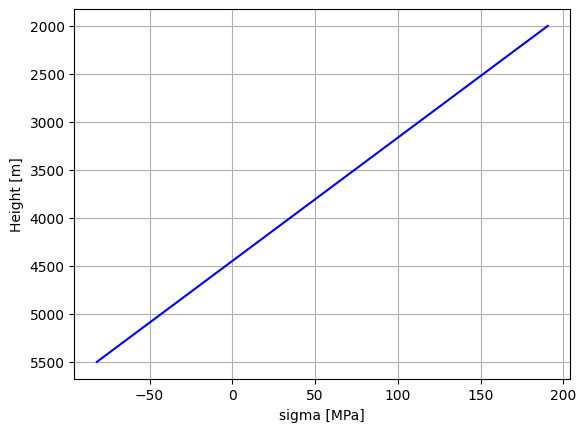

In [3]:
a = (stress_real_top-stress_real_base)/(height_water_above_casing-height_base_casing)

b = stress_real_top - a * height_water_above_casing

# print(a)
# print(b)

depths = np.linspace(height_base_casing, height_water_above_casing, 100)
stresses = a * depths + b

plt.figure()
plt.plot(stresses/1e6, depths, linestyle='-', color='blue')

# Adicionar título e rótulos
# plt.title('')
plt.xlabel('sigma [MPa]')
plt.ylabel(r'Height [m]')
plt.grid(True)
plt.gca().invert_yaxis()  # Inverter o eixo y para que a profundidade aumente para baixo

plt.show()

In [5]:
sigma_y_bottom = -0.077842 * height_base_casing + 346.254
print(sigma_y_bottom)

sigma_y_bottom_model = -0.077842 * 4100 + 346.254
print(sigma_y_bottom_model)

sigma_y_zero = -0.077842 * 4448.1 + 346.254
print(sigma_y_zero)

sigma_y_top_model = -0.077842 * 2500 + 346.254
print(sigma_y_top_model)

sigma_y_top = -0.077842 * height_water_above_casing + 346.254
print(sigma_y_top)

-81.87699999999995
27.101800000000026
0.004999800000007326
151.64900000000003
190.57000000000002


In [ ]:
print(f"Density of steel: {density_steel} kg/m³")
print(f"Density of cement: {density_cement} kg/m³")
print(f"Height of water above casing: {height_water_above_casing} m")
print(f"Length of casing: {length_casing} m")
print(f"Length of cement: {length_cement} m")

print(f"The outer diameter of the pipe is: {outer_diamenter_pipe/0.0254} in")
print(f"The thickness of the pipe is: {thickness_pipe/0.0254} in")

print(f"Stress at the base of the casing: {stress_real_base/1e6} MPa")
print(f"Stress at the top of the casing: {stress_real_top/1e6} MPa")
print(f"The height of the top of the casing is: {-height_water_above_casing} m")
print(f"The height of the base of the casing is: {-height_base_casing} m")

Density of steel: 7935.0 kg/m³
Density of cement: 1900.0 kg/m³
Height of water above casing: 2000.0 m
Length of casing: 3500.0 m
Length of cement: 750.0 m
The outer diameter of the pipe is: 9.874999999999998 in
The thickness of the pipe is: 0.625 in
Stress at the base of the casing: -81.87820388513516 MPa
Stress at the top of the casing: 190.5700211148649 MPa
The height of the top of the casing is: -2000.0 m
The height of the base of the casing is: -5500.0 m


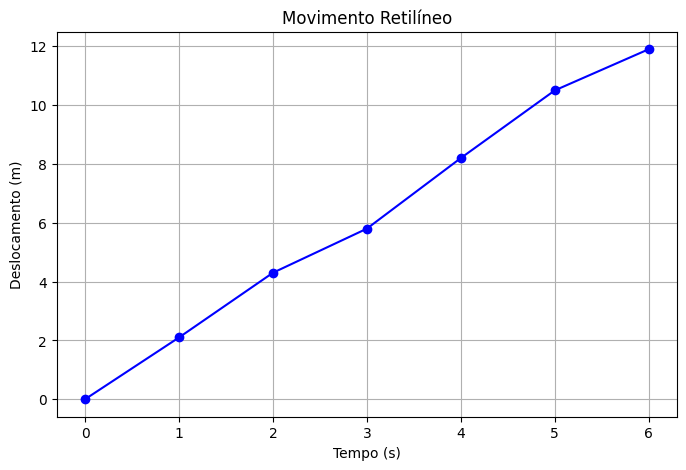

In [3]:
import json 

import matplotlib.pyplot as plt

# 1. Ler e decodificar o conteúdo do arquivo JSON
with open('dadosteste.json', 'r', encoding='utf-8') as arquivo:
    dados_json = json.load(arquivo)

# 2. Extrair os vetores de tempo e deslocamento
t = dados_json['dados']['tempo']
d = dados_json['dados']['deslocamento']

# 3. Extrair os metadados para o título e eixos
nome_experimento = dados_json['nome_experimento']
unidade_t = dados_json['unidades']['tempo']
unidade_d = dados_json['unidades']['deslocamento']

# 4. Configurar e plotar o gráfico
plt.figure(figsize=(8, 5))  # Define o tamanho da figura
plt.plot(t, d, marker='o', linestyle='-', color='blue', linewidth=1.5, markerfacecolor='blue')

# 5. Adicionar título e rótulos aos eixos dinamicamente
plt.title(nome_experimento)
plt.xlabel(f"Tempo ({unidade_t})")
plt.ylabel(f"Deslocamento ({unidade_d})")

# Habilitar a grade (grid)
plt.grid(True)

# 6. Exibir o gráfico na tela
plt.show()

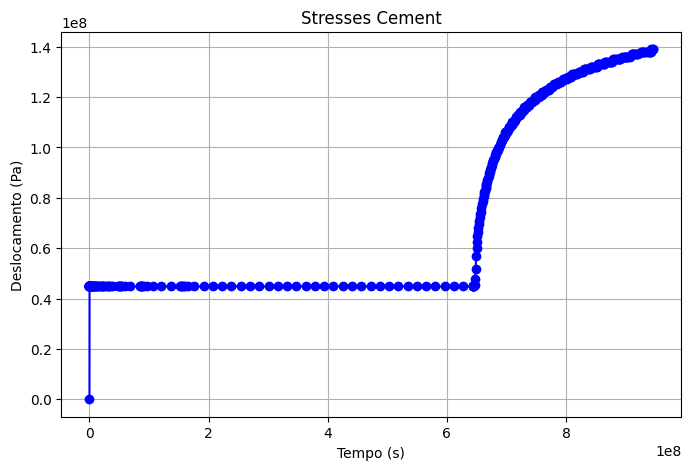

In [4]:
import json 

import matplotlib.pyplot as plt

# 1. Ler e decodificar o conteúdo do arquivo JSON
with open('dados_convertidos.json', 'r', encoding='utf-8') as arquivo:
    dados_json = json.load(arquivo)

# 2. Extrair os vetores de tempo e deslocamento
t = dados_json['dados']['tempo']
d = dados_json['dados']['deslocamento']

# 3. Extrair os metadados para o título e eixos
nome_experimento = dados_json['nome_experimento']
unidade_t = dados_json['unidades']['tempo']
unidade_d = dados_json['unidades']['deslocamento']

# 4. Configurar e plotar o gráfico
plt.figure(figsize=(8, 5))  # Define o tamanho da figura
plt.plot(t, d, marker='o', linestyle='-', color='blue', linewidth=1.5, markerfacecolor='blue')

# 5. Adicionar título e rótulos aos eixos dinamicamente
plt.title(nome_experimento)
plt.xlabel(f"Tempo ({unidade_t})")
plt.ylabel(f"Deslocamento ({unidade_d})")

# Habilitar a grade (grid)
plt.grid(True)

# 6. Exibir o gráfico na tela
plt.show()